# Utiliser les briques du projet

Ce notebook montre comment :
1. Charger les observations d’un moteur.
2. Visualiser ses mesures.
3. Estimer ses six paramètres de santé avec le MLP.

Le MLP prend les conditions de vol et les mesures brutes.
La normalisation est intégrée au modèle.

Les estimations ne constituent pas, à elles seules, un diagnostic
ni une recommandation de maintenance.

In [13]:
import matplotlib.pyplot as plt
from IPython.display import display

from ensai_agentic_student.tools.data import get_measure
from ensai_agentic_student.tools.estimation import estimation_indicateurs_mlp

## 1. Charger une observation

Une trajectoire représente un moteur suivi au fil des vols.
Chaque `timestep` correspond à une observation en cruise.

`get_measure` renvoie un DataFrame :
- une ligne si un instant est demandé ;
- toute la trajectoire sinon.

Les états de santé réels et les étiquettes de scénario ne sont
pas renvoyés par cette brique.

In [14]:
TRAJECTORY_ID = 1
TIMESTEP = 50

observation = get_measure(
    trajectory_id=TRAJECTORY_ID,
    timestep=TIMESTEP,
)

display(observation)

,trajectory_id,timestep,phase,DTAMB,ALT,MACH,COMMAND,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,Convergence,measurements_finite,converged,usable
50,1,50,CR,9.500222,35083.789581,0.766025,24916.053449,797.026361,19439.7851,333.856116,1119.50752,0.367654,1358387.05,Calculation convergence: OK,True,True,True


## 2. Estimer les paramètres de santé

La fonction `estimation_indicateurs_mlp` utilise un modèle préentraîné.
Elle sélectionne les entrées dans le bon ordre et applique ses scalers.

Elle retourne six deltas de santé :
- rendement et débit du compresseur haute pression (CmpH) ;
- rendement et débit de la turbine haute pression (TrbH) ;
- rendement et débit de la turbine basse pression (TrbL).

Zéro correspond à la valeur nominale du paramètre.
Le signe du delta ne suffit pas à déterminer sa gravité.

Le modèle est prévu pour le domaine cruise des données fournies,
avec les paramètres Fan et Booster fixés au nominal.

In [15]:
if observation["usable"].eq(True).all():
    indicateurs = estimation_indicateurs_mlp(observation)
    display(indicateurs)
else:
    print("Observation non exploitable : choisir un autre instant.")

,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
50,-0.001081,-0.000768,-0.001038,0.001668,-0.000552,0.002961


## 3. Explorer une trajectoire complète

Les conditions de vol varient entre les observations.
Une variation de mesure ne correspond donc pas nécessairement
à une dégradation moteur.

`usable` est un indicateur de qualité des données de simulation,
pas une étiquette de panne.

In [16]:
observations = get_measure(trajectory_id=TRAJECTORY_ID)

print(f"Nombre de points : {len(observations)}")
print(f"Points exploitables : {observations['usable'].eq(True).sum()}")

display(observations.head())
display(observations.columns.tolist())

Nombre de points : 300
Points exploitables : 300


,trajectory_id,timestep,phase,DTAMB,ALT,MACH,COMMAND,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,Convergence,measurements_finite,converged,usable
0,1,0,CR,9.448730,35001.348286,0.767930,25070.783875,798.163630,19450.8326,334.251325,1119.89158,0.370108,1369673.84,Calculation convergence: OK,True,True,True
1,1,1,CR,10.227212,34928.540733,0.763977,25034.407282,799.497296,19464.6997,335.077809,1121.63344,0.369388,1365820.57,Calculation convergence: OK,True,True,True
2,1,2,CR,10.226908,34903.198978,0.779809,25059.438395,801.306040,19478.1651,336.449866,1122.57921,0.373801,1383124.33,Calculation convergence: OK,True,True,True
3,1,3,CR,10.052017,35084.565863,0.785031,24981.679559,801.458864,19484.8669,336.316058,1123.12408,0.373598,1381407.89,Calculation convergence: OK,True,True,True
4,1,4,CR,10.621182,34967.795233,0.798717,25052.965407,804.781431,19515.6583,338.528230,1126.11127,0.378844,1400319.49,Calculation convergence: OK,True,True,True


['trajectory_id',
 'timestep',
 'phase',
 'DTAMB',
 'ALT',
 'MACH',
 'COMMAND',
 'HPC_Tout',
 'HP_Nmech',
 'HPC_Tin',
 'LPT_Tin',
 'Fuel_flow',
 'HPC_Pout_st',
 'Convergence',
 'measurements_finite',
 'converged',
 'usable']

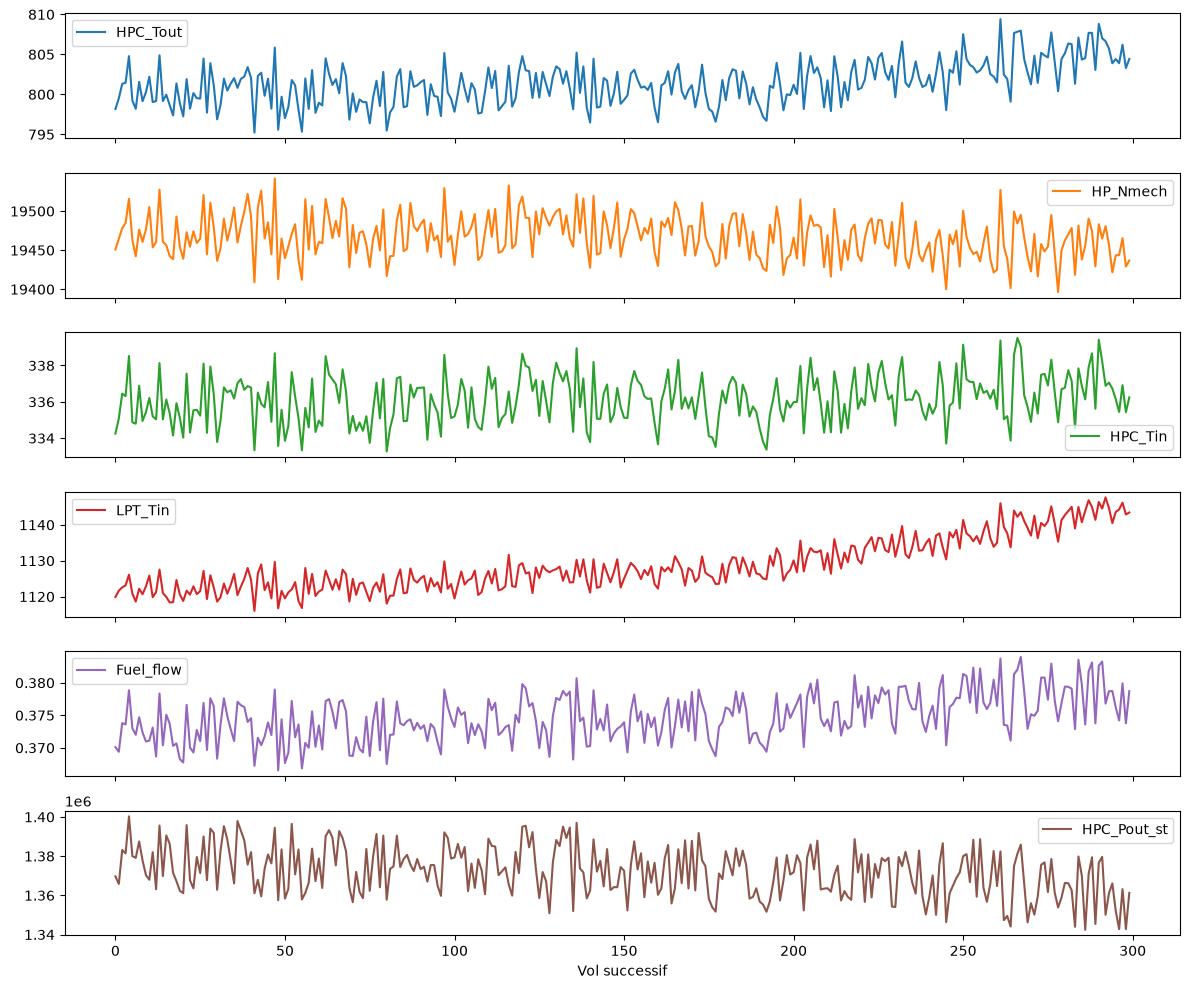

In [17]:
from pathlib import Path
from ensai_agentic_student.mlp_inverse import load_model

# Fonctionne depuis la racine du dépôt ou son dossier notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

model = load_model(ROOT / "models" / "best_model.pt")

conditions = ["DTAMB", "ALT", "MACH", "COMMAND"]
capteurs = [name for name in model.feature_cols if name not in conditions]

# Garder les instants invalides comme des trous dans les courbes.
mesures = observations.set_index("timestep")[capteurs].copy()
mesures.loc[~observations["usable"].eq(True).to_numpy(), :] = float("nan")

mesures.plot(subplots=True, figsize=(12, 10), legend=True)
plt.xlabel("Vol successif")
plt.tight_layout()
plt.show()

## Estimer les indicateurs de santé sur une trajectoire

On applique le MLP à toutes les observations de la trajectoire avec un seul appel à `estimation_indicateurs_mlp`.

La brique gère automatiquement :
- le chargement du modèle et la normalisation des entrées ;
- la sélection des observations exploitables ;
- le retour des six paramètres de santé dans leurs unités d’origine.

Le résultat conserve une ligne par observation. Les estimations des points non exploitables sont remplacées par `NaN`.

Chaque observation est traitée indépendamment : ce MLP n’utilise pas l’historique temporel du moteur.

In [ ]:

estimations = estimation_indicateurs_mlp(observations)
display(estimations.head())

,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,-0.000462,0.000058,-0.000161,-0.000012,-0.000309,0.000749
1,-0.000260,0.000013,0.000139,0.000246,-0.000233,0.000434
2,0.000090,-0.000888,0.000018,0.000098,-0.000629,-0.000724
3,-0.000364,-0.000346,-0.000193,0.000468,-0.000019,0.000980
4,-0.000075,-0.001291,-0.000354,0.000008,-0.000684,-0.000549


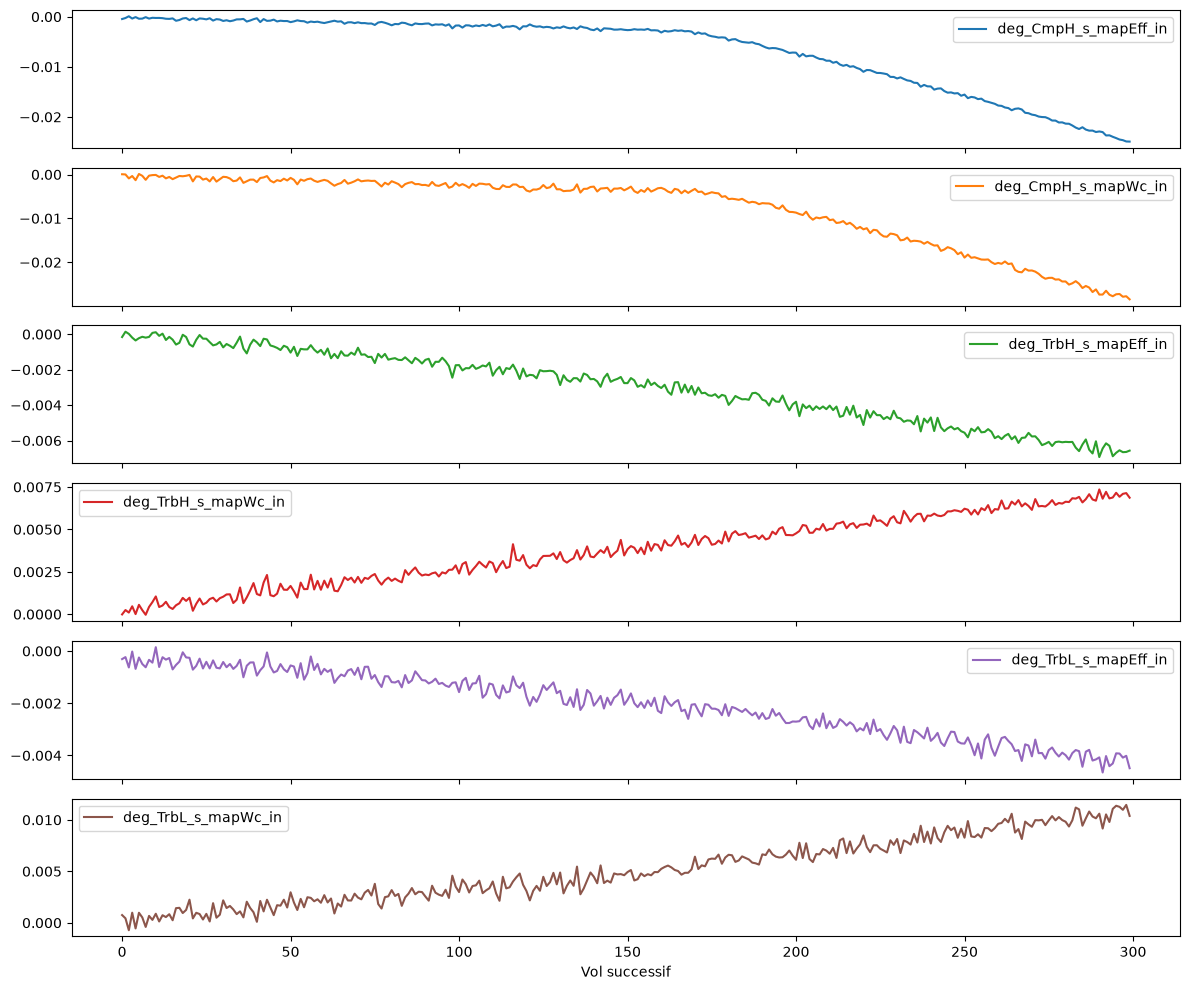

In [19]:
estimations.plot(
    subplots=True,
    figsize=(12, 10),
    legend=True,
)

plt.xlabel("Vol successif")
plt.tight_layout()
plt.show()

## 4. Des estimations à une décision

Le MLP traite chaque observation indépendamment.
Il n'utilise pas l'historique et ne fournit pas d'incertitude.

Sa précision varie selon les paramètres. Un biais capteur peut
également être interprété comme une variation de santé moteur.

À explorer :
- Quels paramètres montrent une évolution persistante ?
- Les variations peuvent-elles s'expliquer par les conditions de vol ?
- Quelles informations supplémentaires permettraient de confirmer
  une anomalie ?
- Quand demander une inspection, et comment justifier cette demande ?

Lors d'une décision au temps t, utiliser uniquement les observations
disponibles jusqu'à t. Les courbes complètes de ce notebook servent
à l'exploration rétrospective.

In [20]:
INSTANT_DECISION = 100

historique = observations.loc[
    (observations["timestep"] <= INSTANT_DECISION)
    & observations["usable"].eq(True)
]

estimations_passees = estimation_indicateurs_mlp(historique)

display(estimations_passees.tail())

,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
96,-0.001795,-0.001938,-0.001525,0.002404,-0.001325,0.003209
97,-0.001512,-0.003020,-0.001801,0.002617,-0.001376,0.002412
98,-0.002334,-0.002741,-0.002454,0.002626,-0.001218,0.004575
99,-0.001765,-0.001890,-0.001751,0.002882,-0.001199,0.003509
100,-0.001741,-0.002554,-0.001743,0.002399,-0.001574,0.002986


## Calculer une marge EGT simplifiée

Pour cet exercice, nous utilisons `LPT_Tin` comme proxy de l’EGT.
Il s’agit d’une hypothèse pédagogique.

La marge est calculée comme la différence entre une température
limite choisie et la température observée :

**marge EGT = température limite − température observée**

- Marge positive : température inférieure à la limite.
- Marge nulle : limite atteinte.
- Marge négative : limite dépassée.

La limite doit être exprimée dans la même unité que le capteur.
Cette version ne corrige pas les effets des conditions de vol :
une baisse de marge ne suffit donc pas à conclure à une dégradation.

Les observations non exploitables sont conservées avec une marge `NaN`.

Nous utilisons une limite pédagogique de 1 150, exprimée dans
la même unité que `LPT_Tin`. Ce choix sert à illustrer la surveillance
d’une marge thermique ; il ne correspond pas à une limite constructeur.

Cette limite reste identique pour tous les moteurs.

In [21]:
from ensai_agentic_student.tools.marge_egt import marge_EGT

# Limite pédagogique provisoire, pas une limite constructeur.
# Même unité que LPT_Tin.
EGT_LIMITE = 1150.0

marges = marge_EGT(
    observations,
    temperature_limite=EGT_LIMITE,
    capteur="LPT_Tin",
)

display(marges.head())

,timestep,temperature_proxy_EGT,marge_EGT
0,0,1119.89158,30.10842
1,1,1121.63344,28.36656
2,2,1122.57921,27.42079
3,3,1123.12408,26.87592
4,4,1126.11127,23.88873


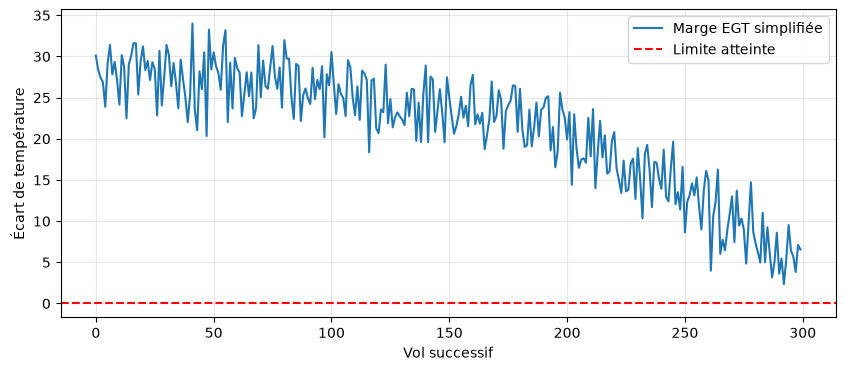

In [22]:
ax = marges.plot(
    x="timestep",
    y="marge_EGT",
    figsize=(10, 4),
    label="Marge EGT simplifiée",
)

ax.axhline(0, color="red", linestyle="--", label="Limite atteinte")
ax.set_xlabel("Vol successif")
ax.set_ylabel("Écart de température")
ax.legend()
ax.grid(alpha=0.3)
plt.show()